## Model 1 

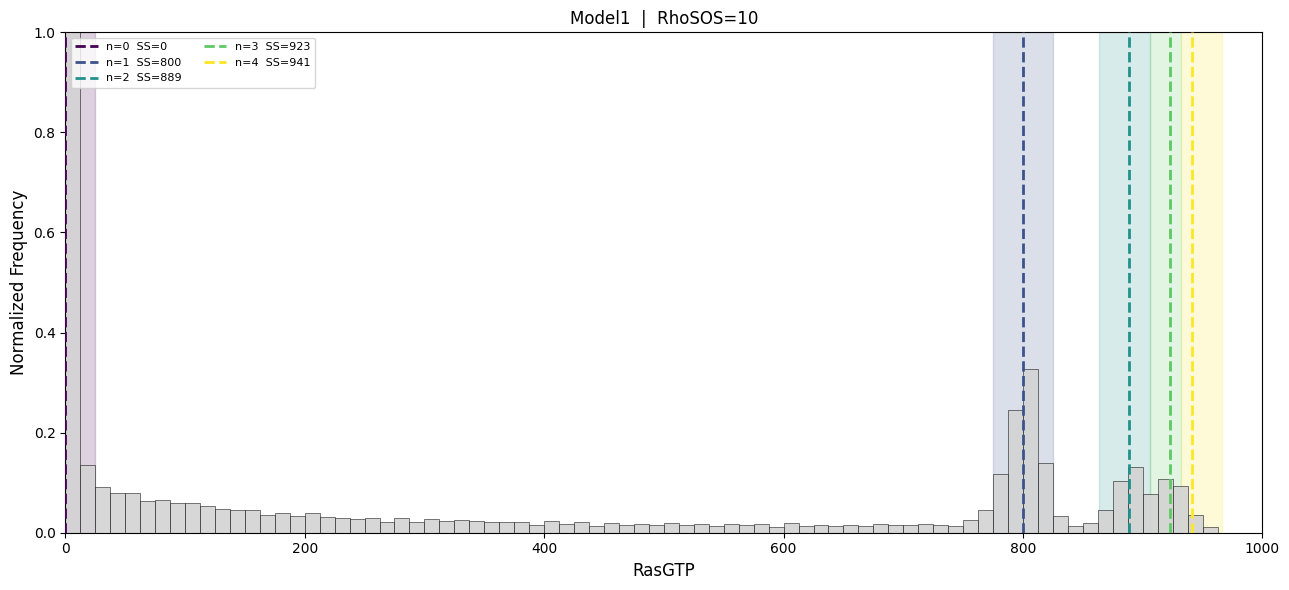

In [ ]:
import bionetgen
import numpy as np
import matplotlib.pyplot as plt

modelName = "Model1"
RasTotal = 1000
RhoSOS = 10
t_end = 100000
n_steps = 10000
Kcat1 = 1e-2
Kcat2 = 2.5e-3
n_bound_list = [0, 1, 2, 3, 4]
ss_tolerance = 25

colors = plt.cm.viridis(np.linspace(0, 1, len(n_bound_list)))

#theoretical SS values
R_ss_array = np.array([
    RasTotal * (n * Kcat1) / (n * Kcat1 + Kcat2) if n > 0 else 0
    for n in n_bound_list
])

#  quantizeed state definitions - default +/- 25 
def nonoverlap_ranges(ss_array, ss_tolerance, RasTotal):
    ranges = []
    for i, ss in enumerate(ss_array):
        lo = ss - ss_tolerance
        hi = ss + ss_tolerance
        if i > 0:
            lo = max(lo, (ss_array[i-1] + ss) / 2)
        if i < len(ss_array) - 1:
            hi = min(hi, (ss + ss_array[i+1]) / 2)
        lo = max(lo, 0)
        hi = min(hi, RasTotal)
        ranges.append((lo, hi))
    return ranges

quantized_ranges = nonoverlap_ranges(R_ss_array, ss_tolerance, RasTotal)

# single sim
model = bionetgen.bngmodel(modelName + ".bngl")
sim = model.setup_simulator()
sim.setIntegrator('gillespie')

seed = np.random.randint(1, 1000000)
sim.integrator.seed = seed
sim.model.setRandomSeed(seed)

sim.RasTotal = RasTotal
sim.RhoSOS   = RhoSOS
sim.reset()

sim.selections = ['time', 'totalRasGTP']
traj = sim.simulate(0, t_end, n_steps)
ras_vals = traj[:, 1]

# histogram
bins = 80
counts, bin_edges = np.histogram(ras_vals, bins=bins, range=(0, RasTotal))
counts_norm = counts / counts.max() if counts.max() > 0 else counts
bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

# plotting
fig, ax = plt.subplots(figsize=(13, 6))

ax.bar(bin_centers, counts_norm, width=np.diff(bin_edges),
       color='lightgrey', edgecolor='black',
       linewidth=0.4, alpha=0.9, zorder=2)

ax.set_ylim(0, 1)

for idx, (n_bound, ss_val, (lo, hi)) in enumerate(
        zip(n_bound_list, R_ss_array, quantized_ranges)):

   
    ax.axvspan(lo, hi, alpha=0.18, color=colors[idx], zorder=1)

   
    ax.axvline(ss_val, color=colors[idx], linewidth=2, linestyle='--', zorder=3,
               label=f"n={n_bound}  SS={ss_val:.0f}")

ax.set_xlabel('RasGTP', fontsize=12)
ax.set_ylabel('Normalized Frequency', fontsize=12)
ax.set_xlim(0, RasTotal)
ax.set_title(f'{modelName}  |  RhoSOS={RhoSOS}', fontsize=12)
ax.legend(fontsize=8, loc='upper left', ncol=2)
plt.tight_layout()
plt.show()

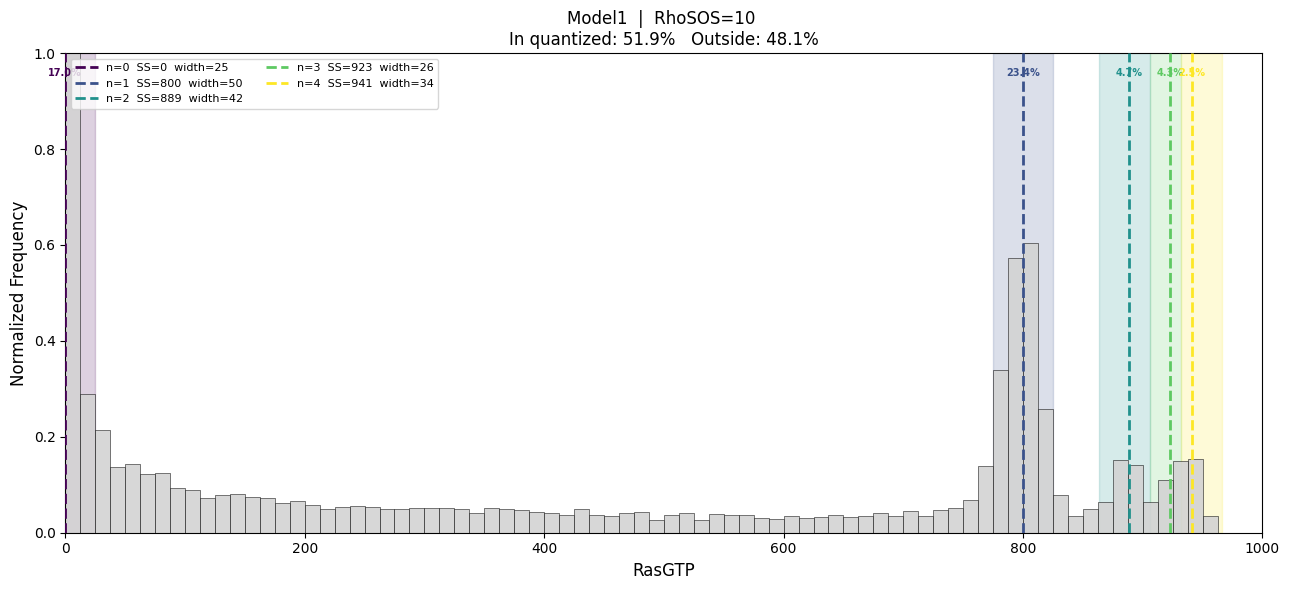


n_bound   SS        range                     width     %
----------------------------------------------------------
0         0.0       [0.0   , 25.0  ]  25.0      17.0%
1         800.0     [775.0 , 825.0 ]  50.0      23.4%
2         888.9     [863.9 , 906.0 ]  42.1      4.7%
3         923.1     [906.0 , 932.1 ]  26.1      4.3%
4         941.2     [932.1 , 966.2 ]  34.0      2.5%

Total in quantized ranges: 51.9%
Total outside quantized:   48.1%


In [75]:
import bionetgen
import numpy as np
import matplotlib.pyplot as plt

modelName = "Model1"
RasTotal = 1000
RhoSOS = 10
t_end = 100000
n_steps = 10000
Kcat1 = 1e-2
Kcat2 = 2.5e-3
n_bound_list = [0, 1, 2, 3, 4]
ss_tolerance = 25

colors = plt.cm.viridis(np.linspace(0, 1, len(n_bound_list)))

#  theoretical SS values 
R_ss_array = np.array([
    RasTotal * (n * Kcat1) / (n * Kcat1 + Kcat2) if n > 0 else 0
    for n in n_bound_list
])

# ranges of quantized states don't overlap, default +/- 25 if not make it midpoint between neighbor so bordering not overlapping 

def build_capped_ranges(ss_array, ss_tolerance, RasTotal):
    ranges = []
    for i, ss in enumerate(ss_array):
        lo = ss - ss_tolerance
        hi = ss + ss_tolerance
        if i > 0:
            lo = max(lo, (ss_array[i-1] + ss) / 2)
        if i < len(ss_array) - 1:
            hi = min(hi, (ss + ss_array[i+1]) / 2)
        lo = max(lo, 0)
        hi = min(hi, RasTotal)
        ranges.append((lo, hi))
    return ranges

quantized_ranges = build_capped_ranges(R_ss_array, ss_tolerance, RasTotal)

#simulatuion 
model = bionetgen.bngmodel(modelName + ".bngl")
sim = model.setup_simulator()
sim.setIntegrator('gillespie')

seed = np.random.randint(1, 1000000)
sim.integrator.seed = seed
sim.model.setRandomSeed(seed)

sim.RasTotal = RasTotal
sim.RhoSOS   = RhoSOS
sim.reset()

sim.selections = ['time', 'totalRasGTP']
traj = sim.simulate(0, t_end, n_steps)
ras_vals = traj[:, 1]

# histogram
bins = 80
counts, bin_edges = np.histogram(ras_vals, bins=bins, range=(0, RasTotal))
counts_norm = counts / counts.max() if counts.max() > 0 else counts
bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

# quantify quantization 
total_intensity    = counts_norm.sum()
total_in_quantized = 0

range_stats = []
for idx, (n_bound, ss_val, (lo, hi)) in enumerate(
        zip(n_bound_list, R_ss_array, quantized_ranges)):
    bin_idx  = np.where((bin_centers >= lo) & (bin_centers <= hi))[0]
    in_count = counts_norm[bin_idx].sum() if len(bin_idx) > 0 else 0
    pct      = 100 * in_count / total_intensity if total_intensity > 0 else 0
    total_in_quantized += in_count
    range_stats.append({
        'n_bound': n_bound,
        'ss_val':  ss_val,
        'lo':      lo,
        'hi':      hi,
        'width':   hi - lo,
        'bin_idx': bin_idx,
        'count':   in_count,
        'pct':     pct
    })

pct_quantized     = 100 * total_in_quantized / total_intensity
pct_non_quantized = 100 - pct_quantized

# plot 
fig, ax = plt.subplots(figsize=(13, 6))

ax.bar(bin_centers, counts_norm,
       width=np.diff(bin_edges),
       color='lightgrey', edgecolor='black',
       linewidth=0.4, alpha=0.9, zorder=2)

ax.set_ylim(0, 1)

for idx, s in enumerate(range_stats):
    ax.axvspan(s['lo'], s['hi'], alpha=0.18, color=colors[idx], zorder=1)

    ax.axvline(s['ss_val'], color=colors[idx], linewidth=2,
               linestyle='--', zorder=3,
               label=f"n={s['n_bound']}  SS={s['ss_val']:.0f}  "
                     f"width={s['width']:.0f}")

    ax.text(s['ss_val'], 0.97, f"{s['pct']:.1f}%",
            ha='center', va='top', fontsize=7,
            color=colors[idx], fontweight='bold', zorder=4)

ax.set_xlabel('RasGTP', fontsize=12)
ax.set_ylabel('Normalized Frequency', fontsize=12)
ax.set_xlim(0, RasTotal)
ax.set_title(
    f'{modelName}  |  RhoSOS={RhoSOS} \n'
    f'In quantized: {pct_quantized:.1f}%   '
    f'Outside: {pct_non_quantized:.1f}%',
    fontsize=12
)
ax.legend(fontsize=8, loc='upper left', ncol=2)
plt.tight_layout()
plt.show()


print(f"\n{'n_bound':<10}{'SS':<10}{'range':<26}{'width':<10}{'%'}")
print("-" * 58)
for s in range_stats:
    print(f"{s['n_bound']:<10}{s['ss_val']:<10.1f}"
          f"[{s['lo']:<6.1f}, {s['hi']:<6.1f}]  "
          f"{s['width']:<10.1f}{s['pct']:.1f}%")

print(f"\nTotal in quantized ranges: {pct_quantized:.1f}%")
print(f"Total outside quantized:   {pct_non_quantized:.1f}%")

In [76]:
#  percentage between 0-bound and 1-bound SOS peaks  
hi_0 = range_stats[0]['hi']   # upper  of n=0 range = 25
lo_1 = range_stats[1]['lo']   # lower  of n=1 range = 775

between_mask  = (bin_centers > hi_0) & (bin_centers < lo_1)
between_count = counts_norm[between_mask].sum()
pct_between   = 100 * between_count / total_intensity

print(f"Between  ({hi_0:.1f}) and ({lo_1:.1f}):")
print(f"% of histogram between 0 and 1-bound SOS peak: {pct_between:.1f}%")

Between  (25.0) and (775.0):
% of histogram between 0 and 1-bound SOS peak: 46.0%


In [77]:
state_occupancy = []

for (lo, hi) in quantized_ranges:
    mask = (ras_vals >= lo) & (ras_vals < hi)
    frac = np.sum(mask) / len(ras_vals)
    state_occupancy.append(frac)


for i, frac in enumerate(state_occupancy):
    print(f"n={n_bound_list[i]} -> {frac*100:.2f}%")

n=0 -> 17.01%
n=1 -> 23.42%
n=2 -> 5.08%
n=3 -> 3.05%
n=4 -> 3.28%


## Model 2 

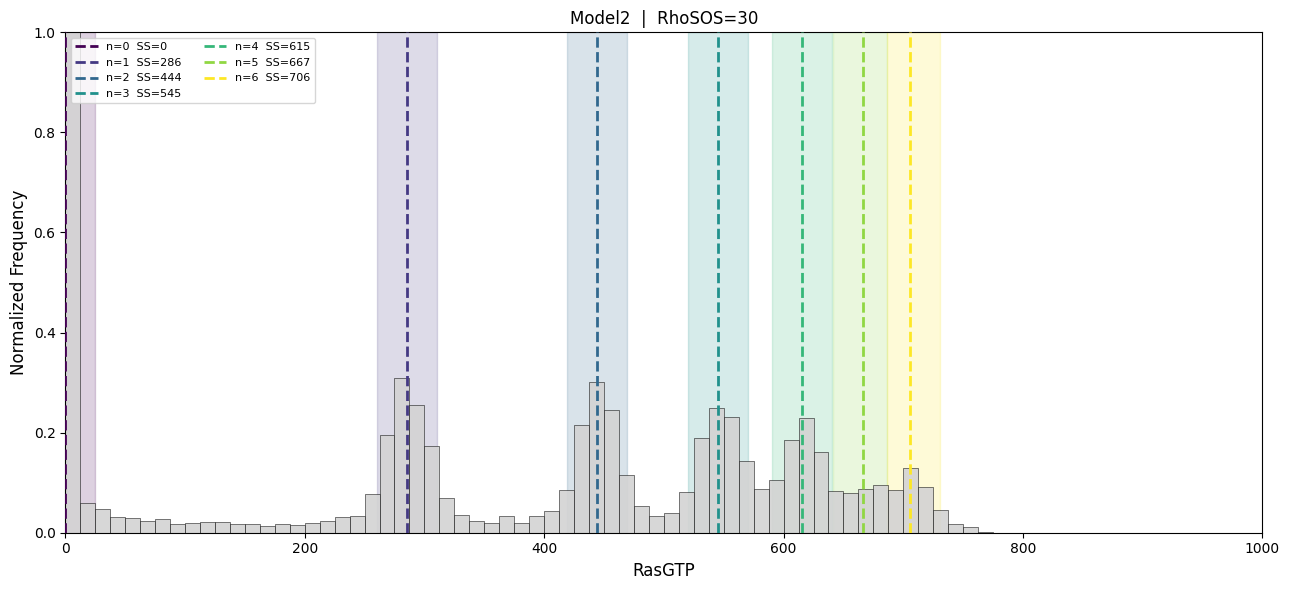

In [78]:
import bionetgen
import numpy as np
import matplotlib.pyplot as plt

modelName = "Model2"
RasTotal = 1000
RhoSOS = 30
t_end = 100000
n_steps = 10000
Kcat1 = 1e-2
Kcat2 = 2.5e-2
n_bound_list = [0, 1, 2, 3, 4, 5, 6]
ss_tolerance = 25

colors = plt.cm.viridis(np.linspace(0, 1, len(n_bound_list)))

#  theoretical SS values 
R_ss_array = np.array([
    RasTotal * (n * Kcat1) / (n * Kcat1 + Kcat2) if n > 0 else 0
    for n in n_bound_list
])

#  ranges not overlapping, 25 either side 
def nooverlap_ranges(ss_array, ss_tolerance, RasTotal):
    ranges = []
    for i, ss in enumerate(ss_array):
        lo = ss - ss_tolerance
        hi = ss + ss_tolerance
        if i > 0:
            lo = max(lo, (ss_array[i-1] + ss) / 2)
        if i < len(ss_array) - 1:
            hi = min(hi, (ss + ss_array[i+1]) / 2)
        lo = max(lo, 0)
        hi = min(hi, RasTotal)
        ranges.append((lo, hi))
    return ranges

quantized_ranges = nooverlap_ranges(R_ss_array, ss_tolerance, RasTotal)

#  simulation 
model = bionetgen.bngmodel(modelName + ".bngl")
sim = model.setup_simulator()
sim.setIntegrator('gillespie')

seed = np.random.randint(1, 1000000)
sim.integrator.seed = seed
sim.model.setRandomSeed(seed)

sim.RasTotal = RasTotal
sim.RhoSOS   = RhoSOS
sim.reset()

sim.selections = ['time', 'totalRasGTP']
traj = sim.simulate(0, t_end, n_steps)
ras_vals = traj[:, 1]

#  histogram 
bins = 80
counts, bin_edges = np.histogram(ras_vals, bins=bins, range=(0, RasTotal))
counts_norm = counts / counts.max() if counts.max() > 0 else counts
bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

## plot
fig, ax = plt.subplots(figsize=(13, 6))

ax.bar(bin_centers, counts_norm,
       width=np.diff(bin_edges),
       color='lightgrey', edgecolor='black',
       linewidth=0.4, alpha=0.9, zorder=2)

ax.set_ylim(0, 1)

for idx, (n_bound, ss_val, (lo, hi)) in enumerate(
        zip(n_bound_list, R_ss_array, quantized_ranges)):

    
    ax.axvspan(lo, hi, alpha=0.18, color=colors[idx], zorder=1) 
    ax.axvline(ss_val, color=colors[idx], linewidth=2,
               linestyle='--', zorder=3,
               label=f"n={n_bound}  SS={ss_val:.0f}")

ax.set_xlabel('RasGTP', fontsize=12)
ax.set_ylabel('Normalized Frequency', fontsize=12)
ax.set_xlim(0, RasTotal)
ax.set_title(f'{modelName}  |  RhoSOS={RhoSOS}', fontsize=12)
ax.legend(fontsize=8, loc='upper left', ncol=2)
plt.tight_layout()
plt.show()

n_bound   SS        gap to next SS    range                     width
----------------------------------------------------------------------
0         0.0       285.7             [0.0   , 25.0  ]  25.0
1         285.7     158.7             [260.7 , 310.7 ]  50.0
2         444.4     101.0             [419.4 , 469.4 ]  50.0
3         545.5     69.9              [520.5 , 570.5 ]  50.0
4         615.4     51.3              [590.4 , 640.4 ]  50.0
5         666.7     39.2              [641.7 , 686.3 ]  44.6
6         705.9     31.0              [686.3 , 721.4 ]  35.1
7         736.8     25.1              [721.4 , 749.4 ]  28.0
8         761.9     0.0               [749.4 , 786.9 ]  37.5


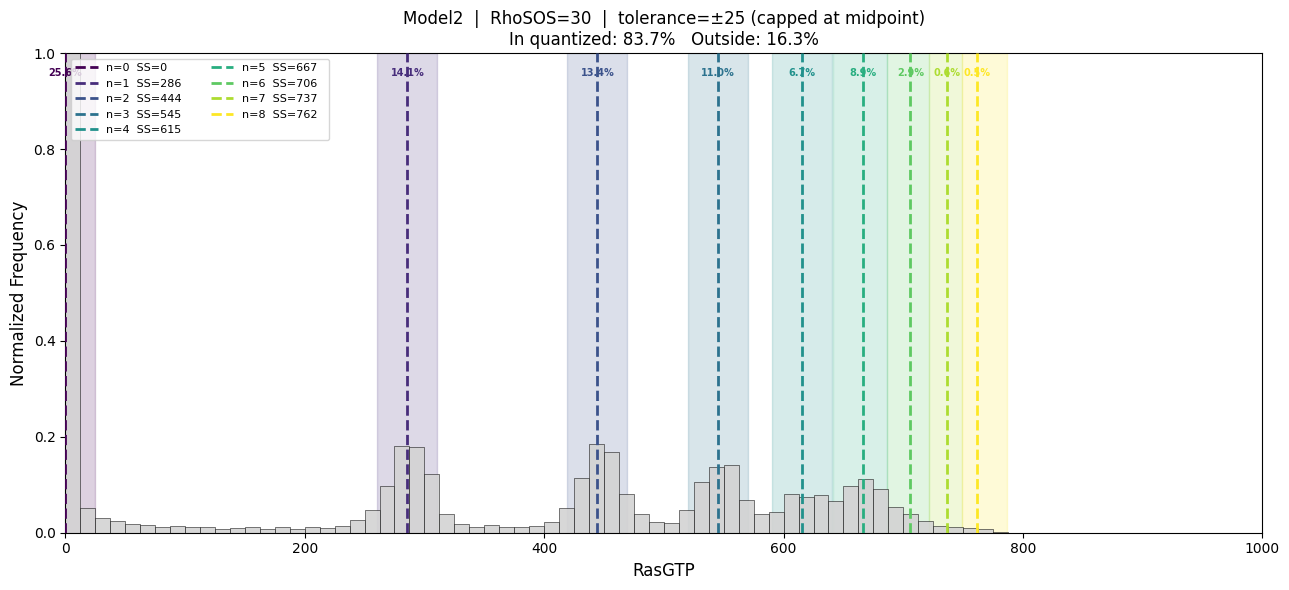


n_bound   SS        range                     width     %
----------------------------------------------------------
0         0.0       [0.0   , 25.0  ]  25.0      25.6%
1         285.7     [260.7 , 310.7 ]  50.0      14.1%
2         444.4     [419.4 , 469.4 ]  50.0      13.4%
3         545.5     [520.5 , 570.5 ]  50.0      11.0%
4         615.4     [590.4 , 640.4 ]  50.0      6.7%
5         666.7     [641.7 , 686.3 ]  44.6      8.9%
6         705.9     [686.3 , 721.4 ]  35.1      2.9%
7         736.8     [721.4 , 749.4 ]  28.0      0.6%
8         761.9     [749.4 , 786.9 ]  37.5      0.5%

Total in quantized ranges: 83.7%
Total outside quantized:   16.3%


In [82]:
import bionetgen
import numpy as np
import matplotlib.pyplot as plt

modelName = "Model2"
RasTotal = 1000
RhoSOS = 30
t_end = 100000
n_steps = 10000
Kcat1 = 1e-2
Kcat2 = 2.5e-2
n_bound_list = [0, 1, 2, 3, 4, 5, 6, 7, 8]
ss_tolerance = 25

colors = plt.cm.viridis(np.linspace(0, 1, len(n_bound_list)))

# theoretical steady state 
R_ss_array = np.array([
    RasTotal * (n * Kcat1) / (n * Kcat1 + Kcat2) if n > 0 else 0
    for n in n_bound_list
])

# default +/- 25 , if not use midpoint between neighbors for border 
def build_capped_ranges(ss_array, ss_tolerance, RasTotal):
    ranges = []
    for i, ss in enumerate(ss_array):
       
        lo = ss - ss_tolerance # default range 
        hi = ss + ss_tolerance

        #  lower bound  midpoint with previous SS
        if i > 0:
            midpoint_left = (ss_array[i-1] + ss) / 2
            lo = max(lo, midpoint_left)

        #  upper bound  midpoint with next SS
        if i < len(ss_array) - 1:
            midpoint_right = (ss + ss_array[i+1]) / 2
            hi = min(hi, midpoint_right)

        lo = max(lo, 0)
        hi = min(hi, RasTotal)

        ranges.append((lo, hi))
    return ranges

quantized_ranges = build_capped_ranges(R_ss_array, ss_tolerance, RasTotal)


print(f"{'n_bound':<10}{'SS':<10}{'gap to next SS':<18}{'range':<26}{'width'}")
print("-" * 70)
for i, (n_bound, ss_val, (lo, hi)) in enumerate(
        zip(n_bound_list, R_ss_array, quantized_ranges)):
    gap = R_ss_array[i+1] - ss_val if i < len(n_bound_list)-1 else 0
    print(f"{n_bound:<10}{ss_val:<10.1f}{gap:<18.1f}"
          f"[{lo:<6.1f}, {hi:<6.1f}]  {hi-lo:.1f}")

# 
model = bionetgen.bngmodel(modelName + ".bngl")
sim = model.setup_simulator()
sim.setIntegrator('gillespie')

seed = np.random.randint(1, 1000000)
sim.integrator.seed = seed
sim.model.setRandomSeed(seed)

sim.RasTotal = RasTotal
sim.RhoSOS   = RhoSOS
sim.reset()

sim.selections = ['time', 'totalRasGTP']
traj = sim.simulate(0, t_end, n_steps)
ras_vals = traj[:, 1]

# histogram
bins = 80
counts, bin_edges = np.histogram(ras_vals, bins=bins, range=(0, RasTotal))
counts_norm = counts / counts.max() if counts.max() > 0 else counts
bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])


total_intensity = counts_norm.sum() 
total_in_quantized = 0

range_stats = []
for idx, (n_bound, ss_val, (lo, hi)) in enumerate(
        zip(n_bound_list, R_ss_array, quantized_ranges)):
    bin_idx  = np.where((bin_centers >= lo) & (bin_centers <= hi))[0]
    in_count = counts_norm[bin_idx].sum() if len(bin_idx) > 0 else 0
    pct      = 100 * in_count / total_intensity if total_intensity > 0 else 0
    total_in_quantized += in_count
    range_stats.append({
        'n_bound': n_bound,
        'ss_val':  ss_val,
        'lo':      lo,
        'hi':      hi,
        'width':   hi - lo,
        'bin_idx': bin_idx,
        'count':   in_count,
        'pct':     pct
    })

pct_quantized     = 100 * total_in_quantized / total_intensity
pct_non_quantized = 100 - pct_quantized

## plotting 
fig, ax = plt.subplots(figsize=(13, 6))

ax.bar(bin_centers, counts_norm,
       width=np.diff(bin_edges),
       color='lightgrey', edgecolor='black',
       linewidth=0.4, alpha=0.9, zorder=2)

ax.set_ylim(0, 1)

for idx, s in enumerate(range_stats):
    ax.axvspan(s['lo'], s['hi'], alpha=0.18, color=colors[idx], zorder=1)

    ax.axvline(s['ss_val'], color=colors[idx], linewidth=2,
               linestyle='--', zorder=3,
               label=f"n={s['n_bound']}  SS={s['ss_val']:.0f}  ")

    ax.text(s['ss_val'], 0.97, f"{s['pct']:.1f}%",
            ha='center', va='top', fontsize=7,
            color=colors[idx], fontweight='bold', zorder=4)

ax.set_xlabel('RasGTP', fontsize=12)
ax.set_ylabel('Normalized Frequency', fontsize=12)
ax.set_xlim(0, RasTotal)
ax.set_title(
    f'{modelName}  |  RhoSOS={RhoSOS}  |  tolerance=±{ss_tolerance} (capped at midpoint)\n'
    f'In quantized: {pct_quantized:.1f}%   '
    f'Outside: {pct_non_quantized:.1f}%',
    fontsize=12
)
ax.legend(fontsize=8, loc='upper left', ncol=2)
plt.tight_layout()
plt.show()


print(f"\n{'n_bound':<10}{'SS':<10}{'range':<26}{'width':<10}{'%'}")
print("-" * 58)
for s in range_stats:
    print(f"{s['n_bound']:<10}{s['ss_val']:<10.1f}"
          f"[{s['lo']:<6.1f}, {s['hi']:<6.1f}]  "
          f"{s['width']:<10.1f}{s['pct']:.1f}%")

print(f"\nTotal in quantized ranges: {pct_quantized:.1f}%")
print(f"Total outside quantized:   {pct_non_quantized:.1f}%")

In [83]:
state_occupancy = []

for (lo, hi) in quantized_ranges:
    mask = (ras_vals >= lo) & (ras_vals < hi)
    frac = np.sum(mask) / len(ras_vals)
    state_occupancy.append(frac)


for i, frac in enumerate(state_occupancy):
    print(f"n={n_bound_list[i]} -> {frac*100:.2f}%")

n=0 -> 25.56%
n=1 -> 13.92%
n=2 -> 13.43%
n=3 -> 11.12%
n=4 -> 6.89%
n=5 -> 8.31%
n=6 -> 2.84%
n=7 -> 0.78%
n=8 -> 0.48%


### old model 2 (Kcat2 and Koff1 = 5e-4)

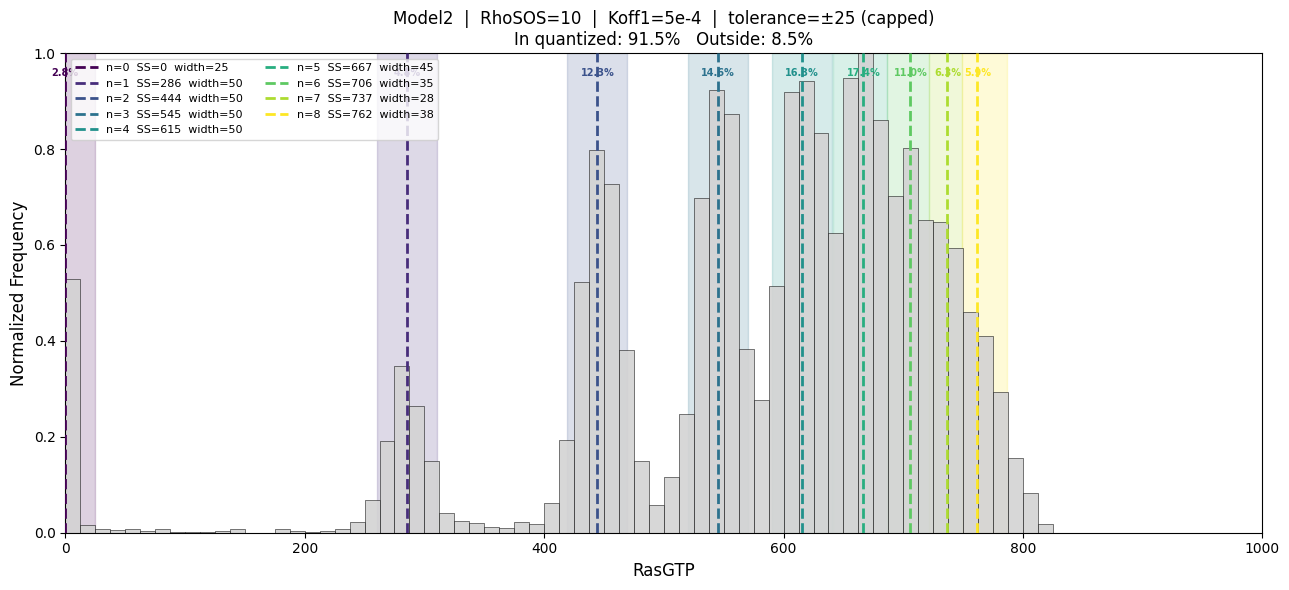


n_bound   SS        range                     width     %
----------------------------------------------------------
0         0.0       [0.0   , 25.0  ]  25.0      2.8%
1         285.7     [260.7 , 310.7 ]  50.0      4.8%
2         444.4     [419.4 , 469.4 ]  50.0      12.3%
3         545.5     [520.5 , 570.5 ]  50.0      14.6%
4         615.4     [590.4 , 640.4 ]  50.0      16.3%
5         666.7     [641.7 , 686.3 ]  44.6      17.4%
6         705.9     [686.3 , 721.4 ]  35.1      11.0%
7         736.8     [721.4 , 749.4 ]  28.0      6.3%
8         761.9     [749.4 , 786.9 ]  37.5      5.9%

Total in quantized ranges: 91.5%
Total outside quantized:   8.5%


In [84]:
import bionetgen
import numpy as np
import matplotlib.pyplot as plt

modelName = "Model2"
RasTotal = 1000
RhoSOS = 10
t_end = 100000
n_steps = 10000
Kcat1 = 1e-2
Kcat2 = 2.5e-2
n_bound_list = [0, 1, 2, 3, 4, 5, 6, 7, 8]
ss_tolerance = 25

colors = plt.cm.viridis(np.linspace(0, 1, len(n_bound_list)))

#  theoretical SS values 
R_ss_array = np.array([
    RasTotal * (n * Kcat1) / (n * Kcat1 + Kcat2) if n > 0 else 0
    for n in n_bound_list
])

def build_capped_ranges(ss_array, ss_tolerance, RasTotal):
    ranges = []
    for i, ss in enumerate(ss_array):
        lo = ss - ss_tolerance
        hi = ss + ss_tolerance
        if i > 0:
            lo = max(lo, (ss_array[i-1] + ss) / 2)
        if i < len(ss_array) - 1:
            hi = min(hi, (ss + ss_array[i+1]) / 2)
        lo = max(lo, 0)
        hi = min(hi, RasTotal)
        ranges.append((lo, hi))
    return ranges

quantized_ranges = build_capped_ranges(R_ss_array, ss_tolerance, RasTotal)

# simulation 
model = bionetgen.bngmodel(modelName + ".bngl")
sim = model.setup_simulator()
sim.setIntegrator('gillespie')

seed = np.random.randint(1, 1000000)
sim.integrator.seed = seed
sim.model.setRandomSeed(seed)

sim.RasTotal = RasTotal
sim.RhoSOS   = RhoSOS
sim.Koff1    = 5e-4
sim.reset()

sim.selections = ['time', 'totalRasGTP']
traj = sim.simulate(0, t_end, n_steps)
ras_vals = traj[:, 1]

# histogram
bins = 80
counts, bin_edges = np.histogram(ras_vals, bins=bins, range=(0, RasTotal))
counts_norm = counts / counts.max() if counts.max() > 0 else counts
bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

# quantify quantized states 
total_intensity    = counts_norm.sum()
total_in_quantized = 0

range_stats = []
for idx, (n_bound, ss_val, (lo, hi)) in enumerate(
        zip(n_bound_list, R_ss_array, quantized_ranges)):
    bin_idx  = np.where((bin_centers >= lo) & (bin_centers <= hi))[0]
    in_count = counts_norm[bin_idx].sum() if len(bin_idx) > 0 else 0
    pct      = 100 * in_count / total_intensity if total_intensity > 0 else 0
    total_in_quantized += in_count
    range_stats.append({
        'n_bound': n_bound,
        'ss_val':  ss_val,
        'lo':      lo,
        'hi':      hi,
        'width':   hi - lo,
        'bin_idx': bin_idx,
        'count':   in_count,
        'pct':     pct
    })

pct_quantized     = 100 * total_in_quantized / total_intensity
pct_non_quantized = 100 - pct_quantized

# plot 
fig, ax = plt.subplots(figsize=(13, 6))

ax.bar(bin_centers, counts_norm,
       width=np.diff(bin_edges),
       color='lightgrey', edgecolor='black',
       linewidth=0.4, alpha=0.9, zorder=2)

ax.set_ylim(0, 1)

for idx, s in enumerate(range_stats):
    ax.axvspan(s['lo'], s['hi'], alpha=0.18, color=colors[idx], zorder=1)

    ax.axvline(s['ss_val'], color=colors[idx], linewidth=2,
               linestyle='--', zorder=3,
               label=f"n={s['n_bound']}  SS={s['ss_val']:.0f}  "
                     f"width={s['width']:.0f}")

    ax.text(s['ss_val'], 0.97, f"{s['pct']:.1f}%",
            ha='center', va='top', fontsize=7,
            color=colors[idx], fontweight='bold', zorder=4)

ax.set_xlabel('RasGTP', fontsize=12)
ax.set_ylabel('Normalized Frequency', fontsize=12)
ax.set_xlim(0, RasTotal)
ax.set_title(
    f'{modelName}  |  RhoSOS={RhoSOS}  |  Koff1=5e-4  |  tolerance=±{ss_tolerance} (capped)\n'
    f'In quantized: {pct_quantized:.1f}%   '
    f'Outside: {pct_non_quantized:.1f}%',
    fontsize=12
)
ax.legend(fontsize=8, loc='upper left', ncol=2)
plt.tight_layout()
plt.show()

# print table 
print(f"\n{'n_bound':<10}{'SS':<10}{'range':<26}{'width':<10}{'%'}")
print("-" * 58)
for s in range_stats:
    print(f"{s['n_bound']:<10}{s['ss_val']:<10.1f}"
          f"[{s['lo']:<6.1f}, {s['hi']:<6.1f}]  "
          f"{s['width']:<10.1f}{s['pct']:.1f}%")

print(f"\nTotal in quantized ranges: {pct_quantized:.1f}%")
print(f"Total outside quantized:   {pct_non_quantized:.1f}%")